## **Comparação entre Otimizadores em MLP**

Vamos comparar os diferentes critérios de otimização, a saber:

*   *SGD*
*   *SGD + Momentum*
*   *SGD + Nesterov*
*   *Adam*

em uma Rede Neural *feedward* para tarefa de classificação no [**Covertype Dataset**](https://archive.ics.uci.edu/dataset/31/covertype).

> Link para artigo sobre os critérios de otimização: https://arxiv.org/pdf/2007.14166

In [1]:
!pip install ucimlrepo

### **Pré-processamento dos dados**

#### **Dataset**

In [2]:
from ucimlrepo import fetch_ucirepo

covertype = fetch_ucirepo(id=31)

X, y = covertype.data.features, covertype.data.targets

In [3]:
print(X.shape)

(581012, 54)


In [4]:
print(y.shape)

(581012, 1)


#### **Dados de Treino e Dados de Teste**

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = y_train - 1
y_test  = y_test - 1

In [28]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (464809, 54)
Teste: (116203, 54)


#### **Padronização dos dados**

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#### **Classe Dataset customizada**

In [7]:
import torch
import torch.nn as nn

In [8]:
from torch.utils.data import Dataset, DataLoader

class CovertypeDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y.values, dtype=torch.long).squeeze()

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


train_dataset = CovertypeDataset(X_train, y_train)
test_dataset = CovertypeDataset(X_test, y_test)

#### **DataLoaders**

In [9]:
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size
)

for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([256, 54])
torch.Size([256])


### **Construção do Modelo**

#### **Fixando parâmetros**

In [10]:
DEVICE = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
LR      = 0.01
EPOCHS  = 50
LOSS_FN = nn.CrossEntropyLoss()

In [11]:
class CovertypeNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
      nn.Linear(54, 128),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(128, 256),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(256, 128),
      nn.ReLU(),
      nn.Linear(128, 7)
    )

  def forward(self, x):
    return self.network(x)

  def reset_weights(self):
        torch.manual_seed(42)
        for layer in self.network:
            if hasattr(layer, 'reset_parameters'):
                layer.reset_parameters()

model = CovertypeNet().to(DEVICE)
print(model)

CovertypeNet(
  (network): Sequential(
    (0): Linear(in_features=54, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=7, bias=True)
  )
)


O modelo foi definido com a seguinte sequência de camadas:

$$
\text{model} = \text{Sequential}\bigl(
    \underbrace{\text{Linear}(54,128)}_{\mathbf{W}^{(1)} \in \mathbb{R}^{128\times54},\; \mathbf{b}^{(1)} \in \mathbb{R}^{128}},
    \operatorname{ReLU},
    \underbrace{\text{Linear}(128,256)}_{\mathbf{W}^{(2)} \in \mathbb{R}^{256\times128},\; \mathbf{b}^{(2)} \in \mathbb{R}^{256}},
    \operatorname{ReLU},
    \underbrace{\text{Linear}(256,128)}_{\mathbf{W}^{(3)} \in \mathbb{R}^{128\times256},\; \mathbf{b}^{(3)} \in \mathbb{R}^{128}}
    \operatorname{ReLU},
    \underbrace{\text{Linear}(128,7)}_{\mathbf{W}^{(4)} \in \mathbb{R}^{7\times128},\; \mathbf{b}^{(4)} \in \mathbb{R}^{7}}
\bigr)
$$

Cada camada $\text{Linear}$ computa:

$$
\mathbf{a}^{(\ell)} = \mathbf{W}^{(\ell)}\mathbf{z}^{(\ell-1)} + \mathbf{b}^{(\ell)}
$$

e a função de ativação é aplicada elemento a elemento:

$$
\mathbf{z}^{(\ell)} = \sigma\!\left(\mathbf{a}^{(\ell)}\right)
$$

### **Função de Treino**

In [12]:
def train_epoch(dataloader, model, loss_fn, optimizer):
  model.train()
  total_loss = 0

  for X, y in dataloader:
    X, y = X.to(DEVICE), y.to(DEVICE)

    pred = model(X)
    loss = loss_fn(pred, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    total_loss += loss.item()

  return total_loss / len(dataloader)

### **Função de Avaliação**

In [13]:
def eval_epoch(loader, model, loss_fn):
  model.eval()
  total_loss = 0

  with torch.no_grad():
    for X, y in loader:
      X, y = X.to(DEVICE), y.to(DEVICE)
      pred = model(X)
      total_loss += loss_fn(pred, y).item()

  n = len(loader.dataset)
  loss = total_loss/len(loader)

  return loss

In [14]:
OPTIMIZERS = {
    "SGD":            lambda p: torch.optim.SGD(p, lr=LR),
    "SGD + Momentum": lambda p: torch.optim.SGD(p, lr=LR, momentum=0.9),
    "SGD + Nesterov": lambda p: torch.optim.SGD(p, lr=LR, momentum=0.9, nesterov=True),
    "Adam":           lambda p: torch.optim.Adam(p, lr=LR),
}

> Sobre os otimizadores disponíveis no *Pytorch*: https://docs.pytorch.org/docs/stable/optim.html

#### **Loop de Epochs para cada Otimizador**

In [15]:
history = {}

for name, opt_fn in OPTIMIZERS.items():
  model.reset_weights()
  optimizer = opt_fn(model.parameters())

  hist = {"train_loss": [], "val_loss": []}
  train_losses = []
  test_losses  = []

  print(f"Model Train with: {name}")

  for t in range(EPOCHS):
      train_loss = train_epoch(train_loader, model, LOSS_FN, optimizer)
      val_loss  = eval_epoch(test_loader, model, LOSS_FN)

      hist["train_loss"].append(train_loss)
      hist["val_loss"].append(val_loss)

      if (t + 1) % 10 == 0:
          print(f"Epoch {t+1:3d}/{EPOCHS} | train: {train_loss:.4f} | test: {val_loss:.4f}")

  print("Done!\n")

  history[name] = hist

Model Train with: SGD
Epoch  10/50 | train: 0.6292 | test: 0.5948
Epoch  20/50 | train: 0.5844 | test: 0.5491
Epoch  30/50 | train: 0.5517 | test: 0.5118
Epoch  40/50 | train: 0.5279 | test: 0.4863
Epoch  50/50 | train: 0.5071 | test: 0.4598
Done!

Model Train with: SGD + Momentum
Epoch  10/50 | train: 0.4701 | test: 0.4070
Epoch  20/50 | train: 0.4156 | test: 0.3466
Epoch  30/50 | train: 0.3910 | test: 0.3155
Epoch  40/50 | train: 0.3758 | test: 0.2999
Epoch  50/50 | train: 0.3653 | test: 0.2870
Done!

Model Train with: SGD + Nesterov
Epoch  10/50 | train: 0.4701 | test: 0.4070
Epoch  20/50 | train: 0.4171 | test: 0.3481
Epoch  30/50 | train: 0.3923 | test: 0.3183
Epoch  40/50 | train: 0.3774 | test: 0.3014
Epoch  50/50 | train: 0.3681 | test: 0.2886
Done!

Model Train with: Adam
Epoch  10/50 | train: 0.4869 | test: 0.4250
Epoch  20/50 | train: 0.4636 | test: 0.3723
Epoch  30/50 | train: 0.4558 | test: 0.3754
Epoch  40/50 | train: 0.4466 | test: 0.3622
Epoch  50/50 | train: 0.4455 | t

### **Curva de Loss para cada Otimizador**

In [16]:
import matplotlib.pyplot as plt

#### **Stochastic Gradient Descent**

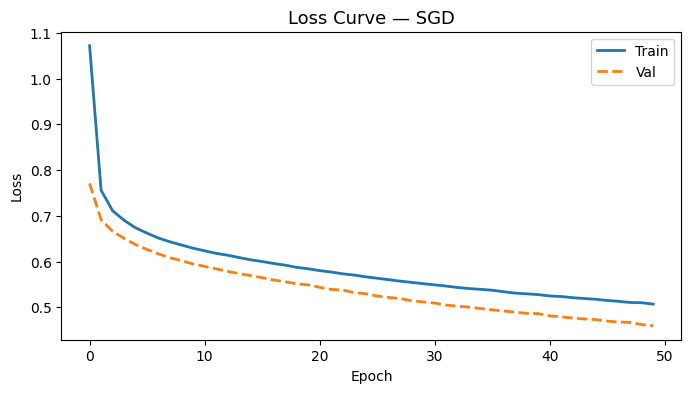

In [35]:
name = "SGD"
hist = history[name]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hist["train_loss"], label="Train", linewidth=2)
ax.plot(hist["val_loss"],   label="Val", linewidth=2, linestyle="--")

ax.set_title(f"Loss Curve — {name}", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

plt.show()

#### **Stochastic Gradient Descent com Momentum**

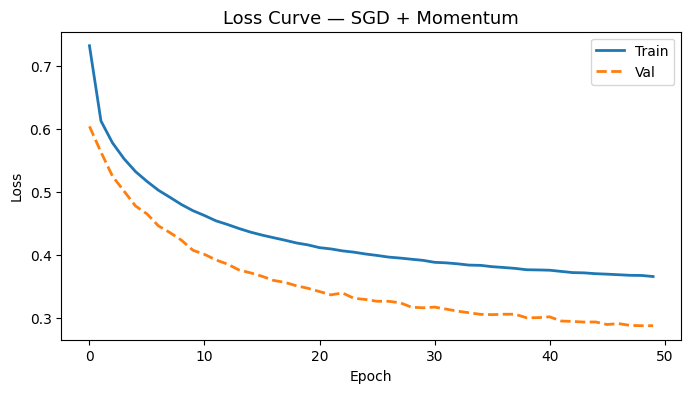

In [36]:
name = "SGD + Momentum"
hist = history[name]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hist["train_loss"], label="Train", linewidth=2)
ax.plot(hist["val_loss"],   label="Val", linewidth=2, linestyle="--")

ax.set_title(f"Loss Curve — {name}", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

plt.show()

#### **Stochastic Gradient Descent com Nesterov**

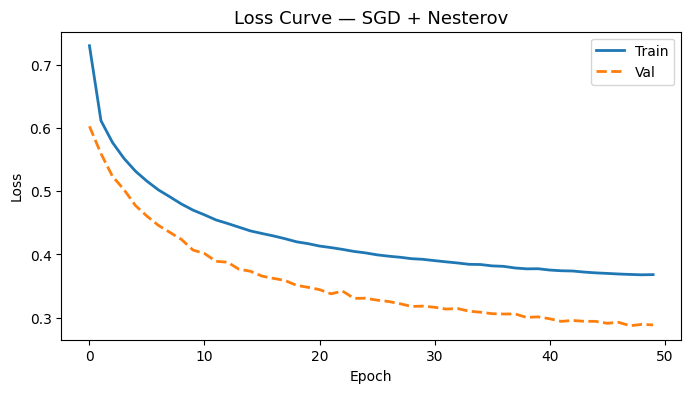

In [37]:
name = "SGD + Nesterov"
hist = history[name]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hist["train_loss"], label="Train", linewidth=2)
ax.plot(hist["val_loss"],   label="Val", linewidth=2, linestyle="--")

ax.set_title(f"Loss Curve — {name}", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

plt.show()

#### **Adam**

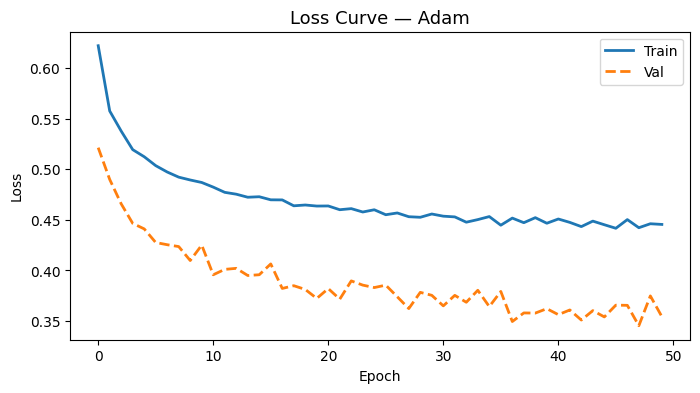

In [38]:
name = "Adam"
hist = history[name]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(hist["train_loss"], label="Train", linewidth=2)
ax.plot(hist["val_loss"],   label="Val", linewidth=2, linestyle="--")

ax.set_title(f"Loss Curve — {name}", fontsize=13)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

plt.show()

### **Comparativo entre as Curvas de Loss no treino para cada Otimizador**

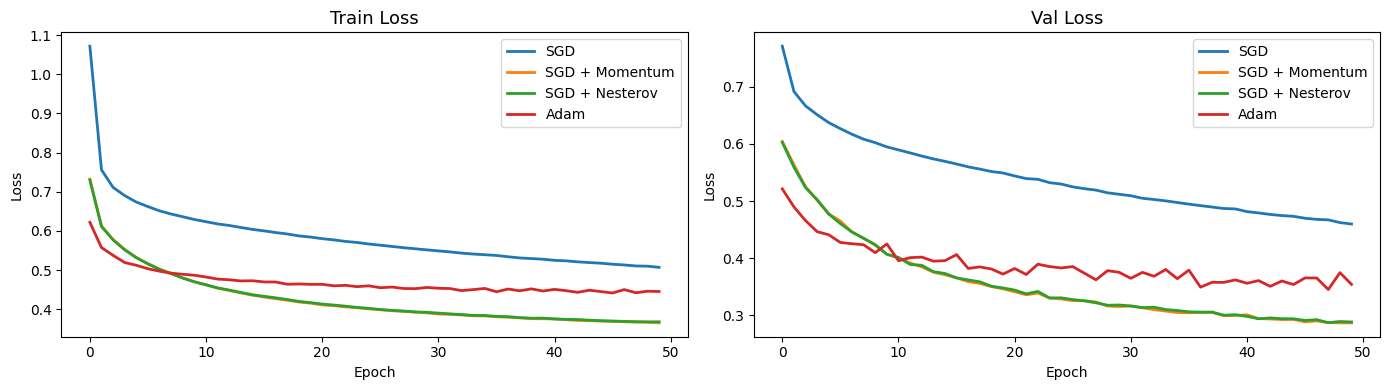

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, data in history.items():
    axes[0].plot(data["train_loss"], label=name, linewidth=2)
    axes[1].plot(data["val_loss"],   label=name, linewidth=2)

for ax, title in zip(axes, ["Train Loss", "Val Loss"]):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()